# Steam Trajectory — Baseline Model (Tier 1)

Predicting month 10-12 engagement from month 1-3 signal. Two models compared:
1. **Baseline**: log-log linear regression using early signal alone — this is the formalized, train/test-split version of the trend line we eyeballed informally in `02_data_visualization.ipynb`
2. **XGBoost**: full feature set (early signal + price + review score + review count + genre)

**Leakage note**: `Peak CCU` and the trajectory shape classification are deliberately excluded from features — see `FeatureBuilder`'s docstring for why. Both would leak future information into the prediction.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("/Users/pmacias/Dropbox/steamproject")
print(os.getcwd())

/Users/pmacias/Dropbox/steamproject


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb

from steam_trajectory.db.connection import get_connection
from steam_trajectory.features.builder import FeatureBuilder

conn = get_connection("steam_project.db")

In [3]:
builder = FeatureBuilder(conn)
X, y = builder.build(early_months=3, late_start=10, late_end=12)

print(f"{len(X)} games, {X.shape[1]} features")
X.head()

380 games, 17 features


,early_avg_players_log,price_usd_launch,review_score_percent,total_reviews_log,genre_Action,genre_Adventure,genre_Casual,genre_Early Access,genre_Free To Play,genre_Indie,genre_Massively Multiplayer,genre_RPG,genre_Racing,genre_Simulation,genre_Sports,genre_Strategy,num_genres
appid,,,,,,,,,,,,,,,,,
12210,3.099062,5.99,82.480706,5.243494,1,1,0,0,0,0,0,0,0,0,0,0,2
244850,3.544805,9.99,88.558109,5.121714,1,0,0,0,0,1,0,0,0,1,0,1,4
261550,4.242996,24.99,87.884989,5.422247,1,0,0,0,0,1,0,1,0,1,0,1,5
268650,2.576374,9.99,88.999410,4.074195,1,1,0,0,0,1,0,0,0,1,0,1,5
311310,2.799672,14.99,54.867780,4.131555,0,0,0,0,0,1,1,0,1,1,0,0,4


## Train/test split
A single random split, not cross-validation — with only ~380 games, this is a real limitation worth being upfront about: a single split's reported metrics can shift noticeably depending on which games happen to land in the test set. Proper k-fold cross-validation is a Tier 2 item.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 304, Test: 76


## Model 1: baseline (early signal only)
Formalizes the trend line from the scatter plot — a single predictor, log-log linear regression.

In [5]:
baseline = LinearRegression()
baseline.fit(X_train[["early_avg_players_log"]], y_train)

baseline_pred = baseline.predict(X_test[["early_avg_players_log"]])

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline — R2: {baseline_r2:.3f}, MAE (log10 players): {baseline_mae:.3f}")

Baseline — R2: 0.589, MAE (log10 players): 0.312


## Model 2: XGBoost (full feature set)
Same target, same train/test split — the only difference is the feature set. If this doesn't meaningfully beat the baseline, that's a real, honest finding: it would mean early engagement alone carries most of the predictive signal, and the extra metadata features aren't adding much.

In [6]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost  — R2: {xgb_r2:.3f}, MAE (log10 players): {xgb_mae:.3f}")
print(f"Baseline — R2: {baseline_r2:.3f}, MAE (log10 players): {baseline_mae:.3f}")

XGBoost  — R2: 0.734, MAE (log10 players): 0.249
Baseline — R2: 0.589, MAE (log10 players): 0.312


## Predicted vs. actual, both models side by side

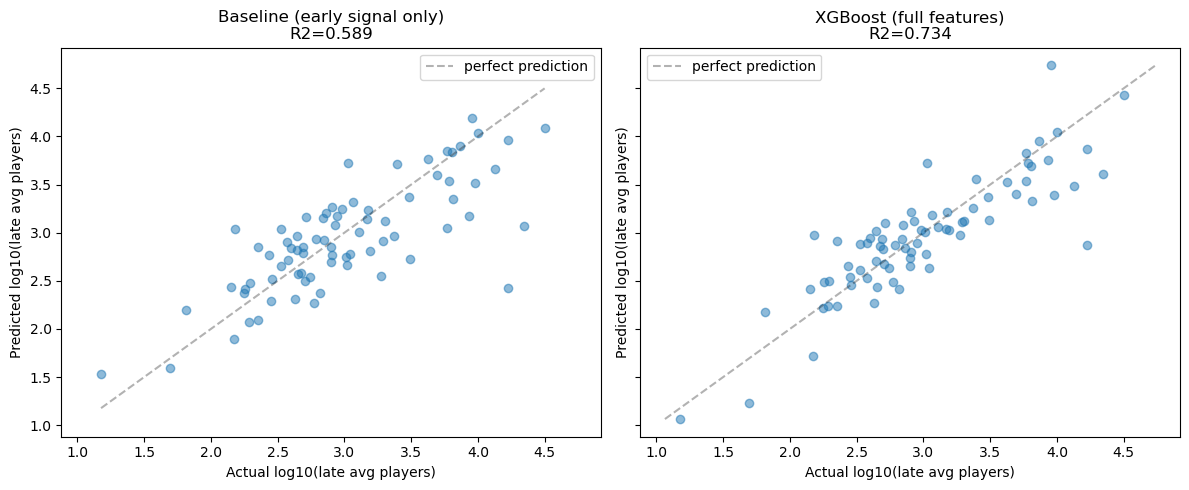

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, pred, title, r2 in [
    (ax1, baseline_pred, "Baseline (early signal only)", baseline_r2),
    (ax2, xgb_pred, "XGBoost (full features)", xgb_r2),
]:
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "k--", alpha=0.3, label="perfect prediction")
    ax.set_xlabel("Actual log10(late avg players)")
    ax.set_ylabel("Predicted log10(late avg players)")
    ax.set_title(f"{title}\nR2={r2:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Quick feature importance preview
XGBoost's built-in importance — a rough first look, not the real interpretability pass. Proper SHAP analysis (which accounts for feature interactions, not just split counts) is a Tier 2 item.

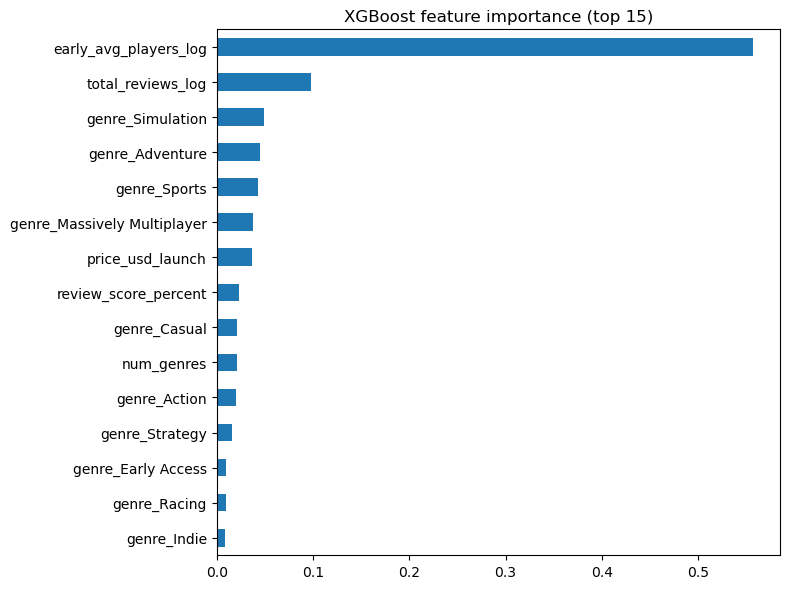

In [8]:
importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.head(15).plot(kind="barh", figsize=(8, 6), title="XGBoost feature importance (top 15)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()